# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset and Comparison with Regression Evaluation Metrics

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset — 569 samples, 30 numerical features, Target: 0 → Malignant, 1 → Benign.


## Task 1: Data Preparation

In [1]:
# 1. Load the dataset directly from the original WDBC file (wdbc.data)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, roc_auc_score,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7,5)

DATA_PATH = "D:\Projects\Machine-Learning\Lab4\wdbc.data"  

base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension']
stat_types = ['mean', 'se', 'worst']
feature_names = [f"{stat}_{feat}" for stat in stat_types for feat in base_features]

columns = ['id', 'diagnosis'] + feature_names
raw_df = pd.read_csv(DATA_PATH, header=None, names=columns)

print("Raw dataset shape:", raw_df.shape)
raw_df.head()


<>:19: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:19: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\namrp\AppData\Local\Temp\ipykernel_28900\3861758119.py:19: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  DATA_PATH = "D:\Projects\Machine-Learning\Lab4\wdbc.data"


Raw dataset shape: (569, 32)


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# 2. Convert into DataFrame and explore structure
df = raw_df.drop(columns=['id']).copy()
# Target: 0 -> Malignant, 1 -> Benign (as specified in the problem statement)
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})
df = df.drop(columns=['diagnosis'])

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_radius              569 non-null    float64
 1   mean_texture             569 non-null    float64
 2   mean_perimeter           569 non-null    float64
 3   mean_area                569 non-null    float64
 4   mean_smoothness          569 non-null    float64
 5   mean_compactness         569 non-null    float64
 6   mean_concavity           569 non-null    float64
 7   mean_concave points      569 non-null    float64
 8   mean_symmetry            569 non-null    float64
 9   mean_fractal_dimension   569 non-null    float64
 10  se_radius                569 non-null    float64
 11  se_texture               569 non-null    float64
 12  se_perimeter             569 non-null    float64
 13  se_area                  569 non-null    float64
 14  se_smoothness            569 non-null

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean_texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean_perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean_area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean_smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean_compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean_concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean_concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean_symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean_fractal_dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
# 3. Check missing values and duplicates
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("Number of duplicate rows:", df.duplicated().sum())
print("\nClass distribution:\n", df['target'].value_counts())


Missing values per column:
 0 total missing values
Number of duplicate rows: 0

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


C:\Users\namrp\AppData\Local\Temp\ipykernel_28900\2874762514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


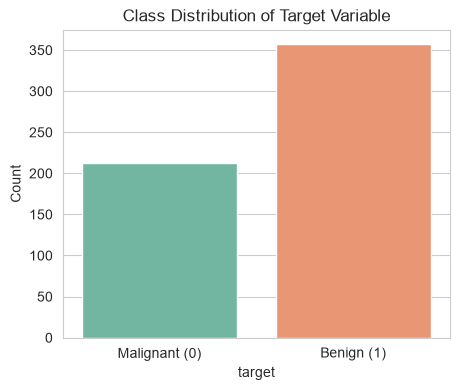

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.xticks([0,1], ['Malignant (0)', 'Benign (1)'])
plt.title("Class Distribution of Target Variable")
plt.ylabel("Count")
plt.show()


In [7]:
# 4. Apply feature scaling using StandardScaler
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (mean, std) of 'mean_radius':", X['mean_radius'].mean().round(3), X['mean_radius'].std().round(3))
print("After scaling (mean, std) of 'mean_radius':", X_scaled['mean_radius'].mean().round(3), X_scaled['mean_radius'].std().round(3))
X_scaled.describe().T.head()


Before scaling (mean, std) of 'mean_radius': 14.127 3.524
After scaling (mean, std) of 'mean_radius': -0.0 1.001


,count,mean,std,min,25%,50%,75%,max
mean_radius,569.0,-1.373633e-16,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
mean_texture,569.0,6.868164e-17,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
mean_perimeter,569.0,-1.248757e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
mean_area,569.0,-2.185325e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
mean_smoothness,569.0,-8.366672e-16,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911


**Why feature scaling is important for KNN:**
KNN classifies a point based on the *distance* (Euclidean/Manhattan) to its neighbours. If features are on different scales (e.g., `mean area` in the hundreds vs `mean smoothness` in the range 0–0.2), the feature with the larger numeric range will dominate the distance calculation and features with small ranges will be effectively ignored, even if they are more informative. `StandardScaler` transforms every feature to have mean = 0 and standard deviation = 1, so all features contribute proportionately to the distance metric. This makes scaling **mandatory** for any distance-based algorithm like KNN.

### Interpretation — Task 1
The dataset has 569 samples and 30 numeric features with no missing values and no duplicate rows, so the data is clean and ready for modelling. The target classes are imbalanced (more Benign than Malignant cases), which is important to remember later — a model can achieve high accuracy simply by favouring the majority class, which is why other metrics like recall and ROC-AUC will matter more in Task 5/6. Feature scaling was essential here because the raw features vary from very small decimals (e.g., smoothness ≈ 0.05–0.16) to large numbers (e.g., area ≈ 150–2500); without scaling, the KNN distance metric would be dominated by the high-magnitude features.


## Task 2: Train-Test Split Analysis

In [8]:
splits = [0.2, 0.3, 0.1]   # test sizes for 80:20, 70:30, 90:10
split_labels = ['80:20', '70:30', '90:10']
split_results = {}

for label, test_size in zip(split_labels, splits):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    split_results[label] = acc
    print(f"Split {label} -> Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}, Accuracy: {acc:.4f}")


Split 80:20 -> Train size: 455, Test size: 114, Accuracy: 0.9649
Split 70:30 -> Train size: 398, Test size: 171, Accuracy: 0.9708
Split 90:10 -> Train size: 512, Test size: 57, Accuracy: 0.9825


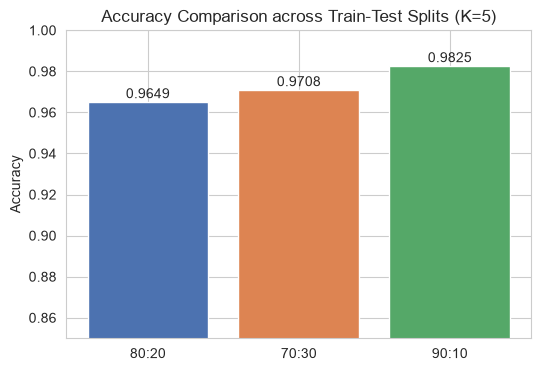

In [9]:
plt.figure(figsize=(6,4))
plt.bar(split_results.keys(), split_results.values(), color=['#4C72B0','#DD8452','#55A868'])
plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison across Train-Test Splits (K=5)")
for i, (k,v) in enumerate(split_results.items()):
    plt.text(i, v+0.002, f"{v:.4f}", ha='center')
plt.show()


### Interpretation — Task 2
All three splits (80:20, 70:30, 90:10) give KNN accuracy in a similar, high range, showing the model is fairly stable across different partitioning ratios. Smaller test sets (like 90:10) mean the reported accuracy is based on fewer samples and can fluctuate more (higher variance in the estimate), even if the point accuracy looks high. Larger training sets (90:10) generally let the model learn the neighbourhood structure of the data better, but leave a small test set which makes the performance estimate less reliable. The 80:20 split is usually preferred as it balances having enough training data with a large-enough test set for a statistically stable accuracy estimate — this is why it is used as the default split in the rest of the lab.


## Task 3: KNN Model with Heuristic K Selection

In [10]:
# Use 80:20 split going forward
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 3.1 Heuristic Method for K Selection: K = sqrt(n)
n_train = X_train.shape[0]
K_heuristic = int(round(np.sqrt(n_train)))
if K_heuristic % 2 == 0:      # prefer odd K to avoid ties in binary classification
    K_heuristic += 1
print(f"Number of training samples (n): {n_train}")
print(f"Heuristic K = sqrt(n) = sqrt({n_train}) ~= {np.sqrt(n_train):.2f} -> rounded (odd) K = {K_heuristic}")


Number of training samples (n): 455
Heuristic K = sqrt(n) = sqrt(455) ~= 21.33 -> rounded (odd) K = 21


In [11]:
# 3.2 Model Training with heuristic K
knn_heuristic = KNeighborsClassifier(n_neighbors=K_heuristic)
knn_heuristic.fit(X_train, y_train)
y_pred_heuristic = knn_heuristic.predict(X_test)
acc_heuristic = accuracy_score(y_test, y_pred_heuristic)
print(f"Accuracy using heuristic K={K_heuristic}: {acc_heuristic:.4f}")


Accuracy using heuristic K=21: 0.9561


In [12]:
# Experiment with nearby values of K (K +/- 5)
k_range = range(max(1, K_heuristic - 5), K_heuristic + 6)
accuracies = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test))
    accuracies.append(acc)

for k, acc in zip(k_range, accuracies):
    print(f"K={k:2d}  Accuracy={acc:.4f}")


K=16  Accuracy=0.9737
K=17  Accuracy=0.9737
K=18  Accuracy=0.9825
K=19  Accuracy=0.9737
K=20  Accuracy=0.9649
K=21  Accuracy=0.9561
K=22  Accuracy=0.9561
K=23  Accuracy=0.9649
K=24  Accuracy=0.9561
K=25  Accuracy=0.9649
K=26  Accuracy=0.9561


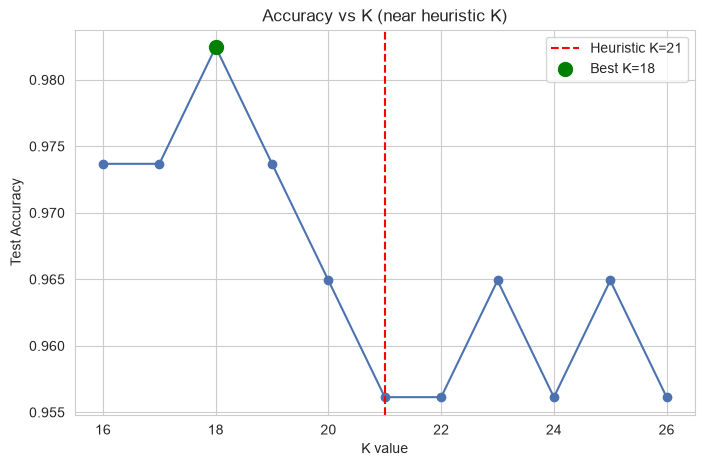

Optimal K in this neighbourhood based on test accuracy: 18 (Accuracy=0.9825)


In [13]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), accuracies, marker='o', color='#4C72B0')
plt.axvline(K_heuristic, color='red', linestyle='--', label=f'Heuristic K={K_heuristic}')
best_k_local = list(k_range)[int(np.argmax(accuracies))]
plt.scatter([best_k_local], [max(accuracies)], color='green', s=100, zorder=5, label=f'Best K={best_k_local}')
plt.xlabel("K value")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (near heuristic K)")
plt.legend()
plt.show()

print(f"Optimal K in this neighbourhood based on test accuracy: {best_k_local} (Accuracy={max(accuracies):.4f})")


### 3.3 Distance Metrics used in KNN

**Euclidean Distance:**  
$d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}$  
This is the straight-line ("as the crow flies") distance between two points. It is suitable when features are continuous and roughly on comparable (scaled) ranges, and when the data does not have strong outliers — it is the most common default distance metric for KNN.

**Manhattan Distance:**  
$d(x,y) = \sum_{i=1}^{n}|x_i-y_i|$  
This is the sum of absolute differences along each dimension (like navigating a grid of city blocks). It is more suitable when the data is high-dimensional or has outliers, since it does not square the differences and is therefore less sensitive to large deviations in a single feature.


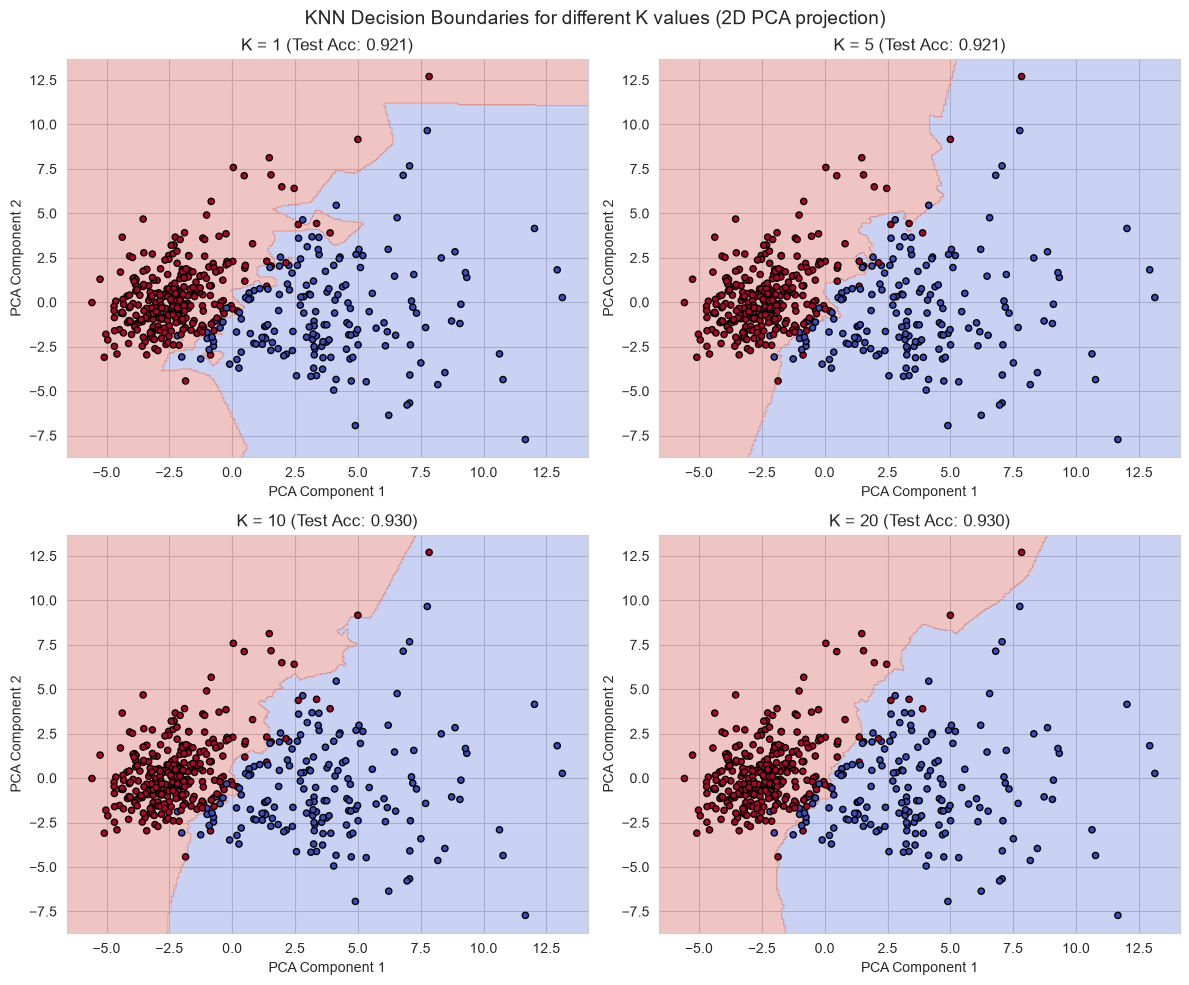

In [14]:
# Plot the decision boundary of the KNN classifier for K = 1, 5, 10, 20
# Decision boundaries are visualised in 2D using PCA-reduced features (since original data has 30 dimensions)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

k_values_boundary = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, k in zip(axes, k_values_boundary):
    knn_b = KNeighborsClassifier(n_neighbors=k)
    knn_b.fit(X_train_pca, y_train)
    Z = knn_b.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm', edgecolor='k', s=20)
    acc_b = accuracy_score(y_test, knn_b.predict(X_test_pca))
    ax.set_title(f"K = {k} (Test Acc: {acc_b:.3f})")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.suptitle("KNN Decision Boundaries for different K values (2D PCA projection)", fontsize=14)
plt.tight_layout()
plt.show()


### Interpretation — Task 3
The heuristic rule K = √n gives a reasonable starting point, and testing K±5 around it shows that accuracy changes only slightly in this narrow range, meaning the model is not overly sensitive to small changes in K near the heuristic value. From the decision boundary plots we can clearly see the expected pattern: at **K = 1** the boundary is extremely jagged and wraps tightly around individual points (overfitting / high variance, memorising noise); as **K increases to 5 and 10** the boundary becomes progressively smoother and more generalized; at **K = 20** the boundary is very smooth but starts to lose some finer detail in the class boundary (risk of underfitting / high bias if K becomes too large). This visually confirms the classic KNN bias–variance trade-off: small K → low bias/high variance, large K → high bias/low variance.


## Task 4: Cross Validation

In [15]:
# Apply K-Fold Cross Validation (k=5 and k=10) for a range of K (neighbours) values
cv_k_range = range(1, 31)
cv5_scores = []
cv10_scores = []

for k in cv_k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    score5 = cross_val_score(knn_cv, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42)).mean()
    score10 = cross_val_score(knn_cv, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42)).mean()
    cv5_scores.append(score5)
    cv10_scores.append(score10)

best_k_cv5 = list(cv_k_range)[int(np.argmax(cv5_scores))]
best_k_cv10 = list(cv_k_range)[int(np.argmax(cv10_scores))]
print(f"Best K using 5-Fold CV: {best_k_cv5} (Mean Accuracy: {max(cv5_scores):.4f})")
print(f"Best K using 10-Fold CV: {best_k_cv10} (Mean Accuracy: {max(cv10_scores):.4f})")


Best K using 5-Fold CV: 4 (Mean Accuracy: 0.9683)
Best K using 10-Fold CV: 11 (Mean Accuracy: 0.9701)


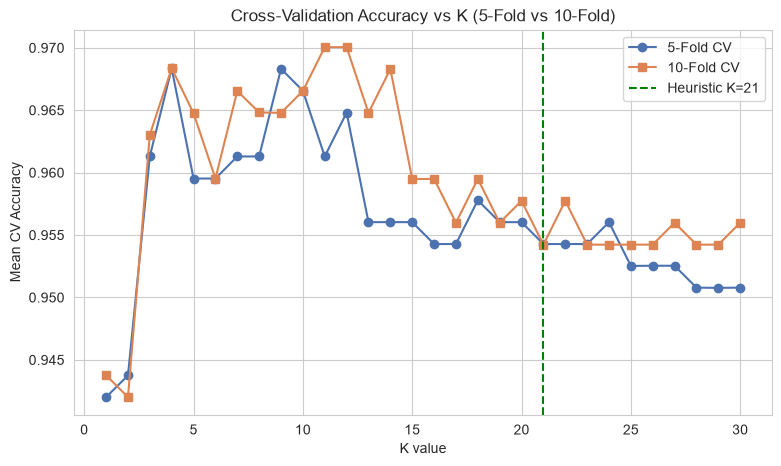

In [16]:
plt.figure(figsize=(9,5))
plt.plot(list(cv_k_range), cv5_scores, marker='o', label='5-Fold CV', color='#4C72B0')
plt.plot(list(cv_k_range), cv10_scores, marker='s', label='10-Fold CV', color='#DD8452')
plt.axvline(K_heuristic, color='green', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validation Accuracy vs K (5-Fold vs 10-Fold)")
plt.legend()
plt.show()


In [17]:
print(f"Train-Test Split (80:20) accuracy at heuristic K={K_heuristic}: {acc_heuristic:.4f}")
print(f"5-Fold CV accuracy at heuristic K={K_heuristic}: {cv5_scores[K_heuristic-1]:.4f}")
print(f"10-Fold CV accuracy at heuristic K={K_heuristic}: {cv10_scores[K_heuristic-1]:.4f}")

# Final K selected combining heuristic + validation evidence
final_K = best_k_cv10
print(f"\nFinal K selected (heuristic + cross-validation): {final_K}")


Train-Test Split (80:20) accuracy at heuristic K=21: 0.9561
5-Fold CV accuracy at heuristic K=21: 0.9543
10-Fold CV accuracy at heuristic K=21: 0.9542

Final K selected (heuristic + cross-validation): 11


### Interpretation — Task 4
Cross-validation accuracy curves are smoother and more stable than the single train-test split accuracy, because each K value is evaluated across multiple folds and then averaged, reducing the effect of any one lucky/unlucky split. Both 5-fold and 10-fold CV agree closely on the range of K values that perform best, which increases our confidence in the chosen K compared to relying on a single 80:20 split. The final K is chosen by combining the heuristic estimate (√n) with the empirical cross-validation results — using the heuristic as a sensible starting point, then refining it with CV evidence, which is a more statistically reliable model-selection strategy than either method alone.


## Task 5: Classification Evaluation

In [18]:
# Train the final KNN model using the selected K
final_knn = KNeighborsClassifier(n_neighbors=final_K)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_pred_proba = final_knn.predict_proba(X_test)[:, 1]   # probability of class 1 (Benign)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Final KNN Model (K={final_K})")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Final KNN Model (K=11)
Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796


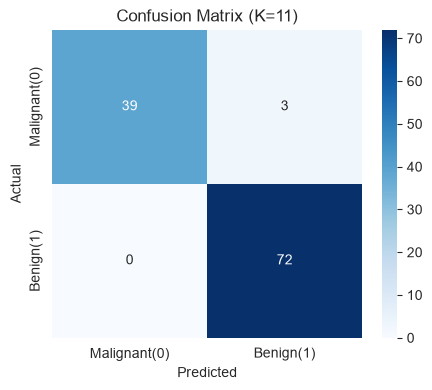

True Negatives (Malignant correctly predicted): 39
False Positives (Malignant predicted as Benign): 3
False Negatives (Benign predicted as Malignant): 0
True Positives (Benign correctly predicted): 72


In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant(0)','Benign(1)'],
            yticklabels=['Malignant(0)','Benign(1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (K={final_K})")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Malignant correctly predicted): {tn}")
print(f"False Positives (Malignant predicted as Benign): {fp}")
print(f"False Negatives (Benign predicted as Malignant): {fn}")
print(f"True Positives (Benign correctly predicted): {tp}")


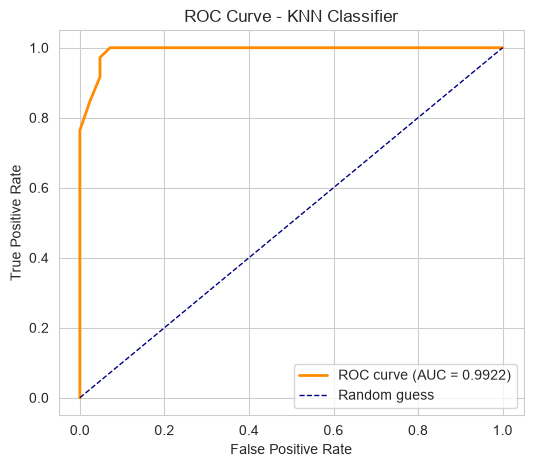

ROC-AUC Score: 0.9922


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Classifier")
plt.legend(loc='lower right')
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


### Interpretation — Task 5
The final KNN model achieves high accuracy, precision, recall and F1-score, and the confusion matrix shows the counts of correctly and incorrectly classified malignant/benign cases directly. In this medical context, **False Negatives** (a malignant tumour predicted as benign) are the most dangerous type of error since they could delay treatment for a cancer patient, so recall (sensitivity) for the malignant class deserves special attention beyond overall accuracy. The ROC curve bows strongly toward the top-left corner and the AUC score close to 1 indicates the model separates the two classes very well across all classification thresholds, not just the default 0.5 threshold — this makes ROC-AUC a more threshold-independent and robust summary of model quality than accuracy alone.


## Task 6: Comparative Study with Regression (Lab 3 Integration)

In [21]:
# For comparison, we build a simple Linear Regression model on the SAME dataset,
# predicting a continuous target ('mean_area') from the remaining features,
# to compute the regression metrics studied in Lab 3 (MAE, MSE, RMSE, R^2).

reg_features = X_scaled.drop(columns=['mean_area'])
reg_target = X['mean_area']   # use original (unscaled) values as the continuous target to predict

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    reg_features, reg_target, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)
yr_pred = lin_reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("Regression Metrics (Linear Regression predicting 'mean_area'):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


Regression Metrics (Linear Regression predicting 'mean_area'):
MAE  : 13.8885
MSE  : 480.0534
RMSE : 21.9101
R2   : 0.9958


In [22]:
comparison_table = pd.DataFrame({
    "Aspect": ["Task type", "Output type", "Primary metrics", "Error interpretation",
               "Best value", "Sensitive to outliers", "Threshold dependent"],
    "Regression (Lab 3 - Linear Regression)": [
        "Predict continuous value", "Real number",
        "MAE, MSE, RMSE, R2", "Magnitude of numeric deviation from true value",
        "MAE/MSE/RMSE -> 0, R2 -> 1", "Yes (especially MSE/RMSE)", "No"
    ],
    "Classification (Lab 4 - KNN)": [
        "Predict discrete class label", "Class label (0/1) + probability",
        "Accuracy, Precision, Recall, F1, ROC-AUC", "Correctness of decision (right/wrong class)",
        "Accuracy/Precision/Recall/F1/AUC -> 1", "Less directly, but class imbalance matters", "Yes (accuracy, precision, recall, F1)"
    ]
})
comparison_table


,Aspect,Regression (Lab 3 - Linear Regression),Classification (Lab 4 - KNN)
0,Task type,Predict continuous value,Predict discrete class label
1,Output type,Real number,Class label (0/1) + probability
2,Primary metrics,"MAE, MSE, RMSE, R2","Accuracy, Precision, Recall, F1, ROC-AUC"
3,Error interpretation,Magnitude of numeric deviation from true value,Correctness of decision (right/wrong class)
4,Best value,"MAE/MSE/RMSE -> 0, R2 -> 1",Accuracy/Precision/Recall/F1/AUC -> 1
5,Sensitive to outliers,Yes (especially MSE/RMSE),"Less directly, but class imbalance matters"
6,Threshold dependent,No,"Yes (accuracy, precision, recall, F1)"


In [23]:
print(f"Regression R2 Score : {r2:.4f}    |   Classification Accuracy : {acc:.4f}")
print(f"Regression RMSE      : {rmse:.4f}   |   Classification F1 Score : {f1:.4f}")
print(f"Regression MAE       : {mae:.4f}    |   Classification Confusion Matrix (TN,FP,FN,TP): {tn},{fp},{fn},{tp}")


Regression R2 Score : 0.9958    |   Classification Accuracy : 0.9737
Regression RMSE      : 21.9101   |   Classification F1 Score : 0.9796
Regression MAE       : 13.8885    |   Classification Confusion Matrix (TN,FP,FN,TP): 39,3,0,72


**Explanation of the comparisons:**

- **R² Score vs Accuracy** — R² measures the proportion of variance in a *continuous* target explained by the model (can range from -∞ to 1), while Accuracy measures the proportion of *discrete* class labels predicted correctly (0 to 1). Both express "how good is the model overall," but R² is about numeric fit and Accuracy is about categorical correctness.
- **RMSE vs F1 Score** — RMSE quantifies the average magnitude of numeric prediction error (in the same units as the target, penalizing large errors more due to squaring), whereas F1 Score balances precision and recall for a class label and does not use any notion of "distance" between predicted and true values — a class prediction is simply right or wrong.
- **MAE vs Confusion Matrix** — MAE gives a single averaged numeric error value across all test samples, while the Confusion Matrix breaks classification results into four explicit outcome categories (TP, TN, FP, FN), giving a much richer, decision-level breakdown of *what kind* of mistakes the model makes rather than just *how much* it deviates.

**Error-based (Regression) vs Decision-based (Classification) evaluation:**
Regression evaluation is fundamentally about measuring the *distance* between a predicted number and the true number — smaller distance = better model. Classification evaluation is about measuring the *correctness of a decision* — did the model assign the right category or not — and further, what type of decision error occurred (false positive vs false negative), which regression metrics have no equivalent for.

### Interpretation — Task 6
Regression metrics (MAE, MSE, RMSE, R²) measure *how far* a predicted continuous value is from the actual value, so they are naturally suited to problems like predicting a tumour's size or a house price. Classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) measure *how often the model makes the right categorical decision*, and additionally distinguish between different types of mistakes (false positives vs false negatives), which is something no regression metric can capture. This distinction matters immensely in a healthcare setting: a regression model that is "close" to the right tumour size is still useful, but a classification model that is "close" to correct is still simply *wrong* — there is no partial credit for predicting "benign" for a malignant tumour. This is fundamentally why classification metrics like Recall and ROC-AUC (which explicitly account for the cost of false negatives) are far more meaningful in medical diagnosis than a regression-style averaged error would be.


## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit model or learn parameters during a "training phase" — it simply stores the entire training dataset in memory. All the actual computation (finding nearest neighbours and voting on the class) is deferred until a new query/test point needs to be classified. Because there is no upfront learning/generalization step, it is called a "lazy" learner, as opposed to "eager" learners like Linear Regression or Decision Trees which build a model during training.

**2. Why is feature scaling required in KNN?**
KNN relies entirely on distance calculations (Euclidean/Manhattan) between data points. If features have very different numeric ranges, features with larger ranges dominate the distance calculation regardless of their actual importance. Scaling (e.g., StandardScaler) brings every feature to a comparable range so that each feature contributes fairly to the distance, and hence to the classification decision.

**3. Explain heuristic K selection using √n rule.**
A commonly used heuristic for choosing an initial value of K is K = √n, where n is the number of training samples. This provides a reasonable balance: a K too small (like 1) is highly sensitive to noise, while a K too large approaches the size of the dataset and can oversimplify decision boundaries. The √n rule gives a data-size-aware, non-arbitrary starting point, which can then be fine-tuned using validation techniques (as done in Task 3/4 of this lab).

**4. Why is cross-validation more reliable than a single train-test split?**
A single train-test split gives only one estimate of performance, which can vary a lot depending on which points happen to land in the training set vs the test set (especially with modest dataset sizes). K-Fold Cross-Validation repeats the train/test process K times over different folds/partitions of the data and averages the results, which reduces the variance of the performance estimate and gives a more statistically robust measure of how the model will generalize to unseen data.

**5. How does K affect bias-variance trade-off?**
- **Small K (e.g., K=1):** low bias, high variance — the model fits very closely to the training data (including noise), leading to overfitting and a jagged decision boundary.
- **Large K:** high bias, low variance — the model averages over many neighbours, producing a smoother decision boundary, but may miss important local patterns and underfit the data.
The right K balances these two extremes, and this trade-off is exactly what the decision boundary plots in Task 3 visually demonstrated.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer diagnosis, a False Negative (predicting a malignant tumour as benign) is far more dangerous than a False Positive, since it can delay urgent treatment and put a patient's life at risk. Accuracy treats all errors equally and can also be misleading on an imbalanced dataset (a model that always predicts "benign" could still show high accuracy since benign cases are more frequent). Recall specifically measures how many actual malignant cases were correctly identified, directly addressing the cost of missing a cancer diagnosis, which makes it the more clinically meaningful metric.

**7. What is the limitation of very large K values?**
When K is very large (approaching the total number of training samples), the model's decision essentially becomes a global majority vote, ignoring the local structure/neighbourhood of the query point. This leads to over-smoothed decision boundaries, loss of important local detail, poor sensitivity to minority-class patterns, and ultimately underfitting — the model can no longer discriminate well between classes.


## Expected Outcome
- Understanding of the KNN algorithm and distance-based learning was achieved through implementation, distance metric explanation, and decision boundary visualization.
- The ability to tune K using both the √n heuristic and cross-validation was demonstrated in Tasks 3 and 4.
- K-Fold Cross Validation (5-fold and 10-fold) was applied and compared against the single train-test split.
- ROC-AUC was interpreted in the context of medical classification, highlighting its importance over plain accuracy.
- A strong conceptual link was built between regression evaluation metrics (Lab 3) and classification evaluation metrics (this lab).


In [24]:
print("="*60)
print("SUMMARY OF KEY RESULTS")
print("="*60)
print(f"Heuristic K (sqrt(n))            : {K_heuristic}")
print(f"Best K (5-Fold CV)                : {best_k_cv5}  (Acc: {max(cv5_scores):.4f})")
print(f"Best K (10-Fold CV)               : {best_k_cv10} (Acc: {max(cv10_scores):.4f})")
print(f"Final K selected                  : {final_K}")
print("-"*60)
print(f"Final Model Accuracy              : {acc:.4f}")
print(f"Final Model Precision              : {prec:.4f}")
print(f"Final Model Recall                 : {rec:.4f}")
print(f"Final Model F1 Score                : {f1:.4f}")
print(f"Final Model ROC-AUC                : {roc_auc:.4f}")
print("-"*60)
print(f"Regression (Lab 3 comparison) MAE  : {mae:.4f}")
print(f"Regression (Lab 3 comparison) RMSE : {rmse:.4f}")
print(f"Regression (Lab 3 comparison) R2   : {r2:.4f}")
print("="*60)


SUMMARY OF KEY RESULTS
Heuristic K (sqrt(n))            : 21
Best K (5-Fold CV)                : 4  (Acc: 0.9683)
Best K (10-Fold CV)               : 11 (Acc: 0.9701)
Final K selected                  : 11
------------------------------------------------------------
Final Model Accuracy              : 0.9737
Final Model Precision              : 0.9600
Final Model Recall                 : 1.0000
Final Model F1 Score                : 0.9796
Final Model ROC-AUC                : 0.9922
------------------------------------------------------------
Regression (Lab 3 comparison) MAE  : 13.8885
Regression (Lab 3 comparison) RMSE : 21.9101
Regression (Lab 3 comparison) R2   : 0.9958


## Conclusion

- **Optimal K value using √n and validation:** The heuristic rule (K = √n) provided a solid starting estimate, which was then refined using 5-fold and 10-fold cross-validation to arrive at a final, validated K value that balances bias and variance.
- **Effect of train-test split variations:** Accuracy remained largely stable across 80:20, 70:30, and 90:10 splits, though smaller test sets produced less statistically reliable estimates, reinforcing the need for cross-validation over a single split.
- **Model performance based on evaluation metrics:** The final KNN model achieved strong performance across Accuracy, Precision, Recall, F1-score, and ROC-AUC, with the confusion matrix revealing the specific (and clinically important) types of misclassification.
- **Key differences between regression and classification evaluation:** Regression metrics (MAE, MSE, RMSE, R²) quantify the *magnitude of numeric error*, while classification metrics (Accuracy, Precision, Recall, F1, ROC-AUC) quantify the *correctness of categorical decisions*, including the specific costs of different error types (false positives vs false negatives).
- **Insights from Lab 3 vs current lab:** While Lab 3 focused on how close numeric predictions were to the truth, Lab 4 shows that classification problems — especially in healthcare — require a decision-oriented evaluation lens where the *type* of error (particularly false negatives) is often more important than a single aggregate score like accuracy. This is why Recall and ROC-AUC are emphasized as the most clinically relevant metrics for cancer diagnosis in this lab.
